In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functools import reduce
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from scipy.stats import ks_2samp

# Weight dynamics under subthreshold TI

In [15]:
carrier = 1000
beat = 5
amplitudes = [ 0.5, 0.9 ]
frequencies = np.arange(1, 26)
cell_ids = np.arange(0, 20)

In [16]:
def expand_time(original, max_time = 10_000, time_step = 0.025):
  original["Time"] = (original["Time"] / time_step).round() * time_step
  original = original.sort_values("Time")

  new_time = np.arange(0, max_time + time_step, time_step)

  expanded = pd.DataFrame({ "Time": new_time })
  expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

  return expanded

In [17]:
stims = [f"{carrier}_{beat}_{amplitude}" for amplitude in amplitudes] + ["noTI"]
weights = {}
for stim in stims:
  print(f"Processing stimulus {stim}")
  weights[ stim ] = {}
  for frequency in frequencies:
    print(f"Processing frequency {frequency} Hz")
    cell_weights = []
    for cell_id in cell_ids:
      filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_weights.csv"
      
      df = pd.read_csv(filename, index_col = 0)
      df = expand_time(df).set_index("Time")

      # make synapse columns unique per cell
      syn_cols = [c for c in df.columns if c != "Time"]
      df = df.rename(columns={c: f"{c}_cell{cell_id}" for c in syn_cols})

      cell_weights.append(df)

    # merge all on Time
    cell_weights = reduce(lambda left, right: pd.merge(left, right, on="Time", how="inner"), cell_weights)
    weights[ stim ][ frequency ] = cell_weights

Processing stimulus 1000_5_0.5
Processing frequency 1 Hz
Processing frequency 2 Hz
Processing frequency 3 Hz
Processing frequency 4 Hz
Processing frequency 5 Hz
Processing frequency 6 Hz
Processing frequency 7 Hz
Processing frequency 8 Hz
Processing frequency 9 Hz
Processing frequency 10 Hz
Processing frequency 11 Hz
Processing frequency 12 Hz
Processing frequency 13 Hz
Processing frequency 14 Hz
Processing frequency 15 Hz
Processing frequency 16 Hz
Processing frequency 17 Hz
Processing frequency 18 Hz
Processing frequency 19 Hz
Processing frequency 20 Hz
Processing frequency 21 Hz


FileNotFoundError: [Errno 2] No such file or directory: '../output/temporal-interference-1/0/random_poisson/21/1000_5_0.5_0.1/synapse_weights.csv'

In [6]:
def categorize(w):
  if w > 0.7:
    return "strong LTP"
  elif 0.4 < w <= 0.7:
    return "medium LTP"
  elif 0.1 < w <= 0.4:
    return "weak LTP"
  elif w == 0.1:
    return "no change"
  else:
    return "LTD"

order = [
  "LTD",
  "no change",
  "weak LTP",
  "medium LTP",
  "strong LTP"
]

palette = {
  "LTD": "#0D0887",
  "no change": "#CCCCCC",
  "weak LTP": "#FCA636",
  "medium LTP": "#E16462",
  "strong LTP": "#B12A90"
}

In [7]:
def plot_weight_heatmap(ax, df, categorize, palette, show_cbar=False, show_ylabel = True):
  heatmap_df = df.T.copy()

  final_weights = heatmap_df.iloc[:, -1]
  heatmap_df = heatmap_df.loc[final_weights.sort_values(ascending=False).index]
  final_weights = heatmap_df.iloc[:, -1]

  categories = final_weights.apply(categorize)
  row_colors = categories.map(palette)

  cmap = LinearSegmentedColormap.from_list(
    "custom_weights",
    [
      (0.0, "#0D0887"),
      (0.1, "#CCCCCC"),
      (0.2, "#FCA636"),
      (0.7, "#E16462"),
      (1.0, "#B12A90")
    ]
  )

  im = ax.imshow(
    heatmap_df.values,
    aspect = "auto",
    cmap = cmap,
    vmin = 0,
    vmax = 1
  )

  # row colors on right
  for i, color in enumerate(row_colors):
    ax.add_patch(
      plt.Rectangle(
        (heatmap_df.shape[1], i),
        0.5,
        1,
        color = color,
        transform = ax.transData,
        clip_on = False
      )
    )

  # x ticks
  time_values = heatmap_df.columns.values / 1000
  ticks = np.linspace(0, len(time_values) - 1, 6).astype(int)
  labels = np.round(np.linspace(time_values[0], time_values[-1], 6), 1)

  ax.set_xticks(ticks)
  ax.set_xticklabels(labels)

  ax.set_yticks([])
  if show_ylabel:
    ax.set_ylabel("Synapse")

  ax.set_xlabel("Time (s)")

  if show_cbar:
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Weight")

  return im

## Do the weight distributions at the end of the simulation period differ?

In [8]:
ks = {}
for stim in [ f"{carrier}_{beat}_{amplitude}" for amplitude in amplitudes ]:
  ks[ stim ] = {}
  for frequency in frequencies:
    last_second = np.where(weights[stim][frequency].index / 1000 >= 9.5)[0]
    ti = np.abs(weights[stim][frequency].iloc[last_second, :] - 0.1).mean(axis = 0)
    no_ti = np.abs(weights["noTI"][frequency].iloc[last_second, :] - 0.1).mean(axis = 0)

    stat, p_val = ks_2samp(no_ti, ti)
    ks[ stim ][ frequency ] = pd.DataFrame({
      "Statistic": [stat],
      "P": [p_val],
      "Frequency": [frequency],
      "Condition": [stim]
    })
  
  ks[ stim ] = pd.concat(ks[ stim ].values(), ignore_index=True)

ks_result = pd.concat(ks.values(), ignore_index=True)
ks_result

,Statistic,P,Frequency,Condition
0,0.045,9.877895e-01,1,1000_5_0.5
1,0.105,2.205412e-01,2,1000_5_0.5
2,0.140,3.956203e-02,3,1000_5_0.5
3,0.160,1.184345e-02,4,1000_5_0.5
4,0.155,1.625846e-02,5,1000_5_0.5
5,0.180,3.009847e-03,6,1000_5_0.5
6,0.150,2.209236e-02,7,1000_5_0.5
7,0.150,2.209236e-02,8,1000_5_0.5
8,0.125,8.783828e-02,9,1000_5_0.5
9,0.110,1.779335e-01,10,1000_5_0.5


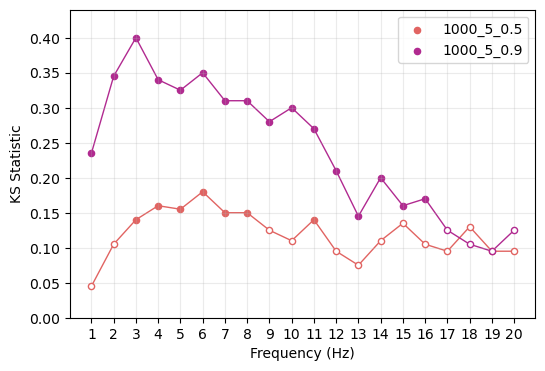

In [9]:
fig, ax = plt.subplots(figsize = (6, 4))

colors = {
  f"{carrier}_{beat}_0.5": "#E16462",
  f"{carrier}_{beat}_0.9": "#B12A90"
}

for stim in [ f"{carrier}_{beat}_{amplitude}" for amplitude in amplitudes ]:
  stim_result = ks_result[ks_result.Condition == stim]
  sig = stim_result[stim_result.P < 0.05]
  nonsig = stim_result[stim_result.P >= 0.05]

  ax.plot(
    stim_result.Frequency,
    stim_result.Statistic,
    color = colors[stim],
    linewidth = 1,
    zorder = 1
  )

  ax.scatter(
      sig.Frequency,
      sig.Statistic,
      color = colors[stim],
      label = f"{stim}",
      s = 20
  )

  ax.scatter(
      nonsig.Frequency,
      nonsig.Statistic,
      facecolors = "white",
      edgecolors = colors[stim],
      s = 20,
      alpha = 1,
      zorder = 5
  )

ax.legend()
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("KS Statistic")
ax.set_xticks(frequencies)
ax.grid(alpha = 0.25)
ax.set_ylim(0, 0.44)
plt.show()

In [10]:
def categorize_potentiation(w):
  if w == 0.1: return "No change"
  return "Change"

categories = ["No change", "Change"]

stimulations = ["noTI"] + [ f"{carrier}_{beat}_{amplitude}" for amplitude in amplitudes ]
weight_categories = {}
for stim in stimulations:
  weight_categories[stim] = {}
  for frequency in frequencies:
    weight_categories[stim][frequency] = pd.DataFrame({
      "Category": weights[stim][frequency].iloc[-1, :].apply(categorize_potentiation),
      "Frequency": frequency,
      "Stimulation": stim
    })

  weight_categories[stim] = pd.concat(weight_categories[stim], ignore_index = True)

weight_categories = pd.concat(weight_categories, ignore_index = True)

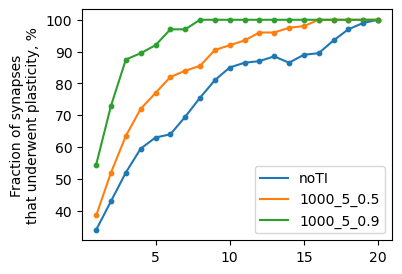

In [11]:
import seaborn as sns

# compute fractions for all stimulations
fractions_all = []

for stimulation in stimulations:
  categories = weight_categories[
    weight_categories.Stimulation == stimulation
  ]
  
  counts = categories.groupby(["Frequency", "Category"]).size().unstack(fill_value=0)
  fractions = counts.div(counts.sum(axis=1), axis=0).reset_index()
  
  fractions["Stimulation"] = stimulation
  fractions_all.append(fractions)

fractions_all = pd.concat(fractions_all, ignore_index=True)

# long format
fractions_long = fractions_all.melt(
  id_vars=["Frequency", "Stimulation"],
  var_name="Category",
  value_name="Fraction"
)

fig, ax = plt.subplots(
  nrows=1,
  ncols=1,
  figsize=(4, 3),
  sharey=True
)

data = fractions_long[fractions_long.Category == "Change"]

for stimulation in stimulations:
  stim_data = data[ data.Stimulation == stimulation ]
  ax.plot(
    stim_data.Frequency,
    stim_data.Fraction * 100,
    label = stimulation
  )

  ax.scatter(
    stim_data.Frequency,
    stim_data.Fraction * 100,
    s = 10
  )

ax.legend()
ax.set_ylabel("Fraction of synapses\nthat underwent plasticity, %")
plt.show()

## Gain

In [12]:
gains = {}
for stim in ["1000_5_0.5", "1000_5_0.9"]:
  gains[stim] = {}
  for f in frequencies:
    change_ti = np.abs(weights[stim][f].iloc[-1, :] - 0.1)
    change_noti = np.abs(weights["noTI"][f].iloc[-1, :] - 0.1)

    # gain = change_ti - change_noti
    gains[stim][f] = pd.DataFrame({
      "GainTI": change_ti,
      "GainNoTI": change_noti,
      "Frequency": f,
      "Stim": stim
    })

  gains[stim] = pd.concat(gains[stim], ignore_index = True)

gains = pd.concat(gains, ignore_index = True)

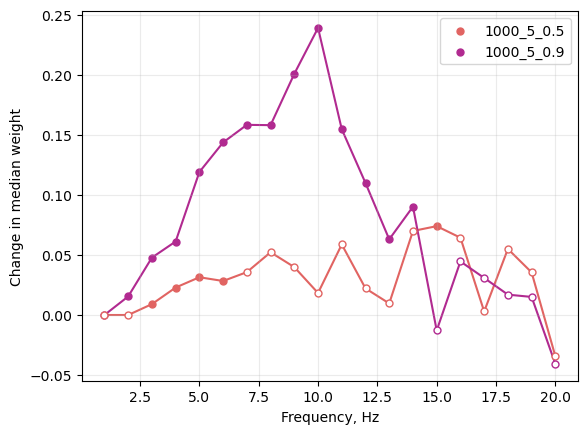

In [13]:
from scipy.stats import mannwhitneyu

colors = {
  f"{carrier}_{beat}_0.5": "#E16462",
  f"{carrier}_{beat}_0.9": "#B12A90"
}

plot_data = []
for stim in ["1000_5_0.5", "1000_5_0.9"]:
  for f in frequencies:
    stim_gains = gains[gains.Stim == stim]
    stim_gains = stim_gains[ stim_gains.Frequency == f ]
    stat, p = mannwhitneyu(stim_gains.GainNoTI, stim_gains.GainTI)
    plot_data.append(pd.DataFrame({
      "Stim": [stim],
      "Frequency": f,
      "Difference": np.median(stim_gains.GainTI) - np.median(stim_gains.GainNoTI),
      "P": p
    }))

plot_data = pd.concat(plot_data, ignore_index = True)

for stim in ["1000_5_0.5", "1000_5_0.9"]:
  dt = plot_data[plot_data.Stim == stim]
  sig = dt[dt.P < 0.05]
  nonsig = dt[dt.P >= 0.05]

  plt.plot(
    dt.Frequency, dt.Difference,
    color = colors[stim],
    zorder = 1
  )

  plt.scatter(
    sig.Frequency,
    sig.Difference,
    color = colors[stim],
    label = f"{stim}",
    s = 25
  )

  plt.scatter(
    nonsig.Frequency,
    nonsig.Difference,
    facecolors = "white",
    edgecolors = colors[stim],
    s = 25,
    alpha = 1,
    zorder = 5
  )

plt.xlabel("Frequency, Hz")
plt.ylabel("Change in median weight")
plt.grid(alpha = 0.25)
plt.legend()
plt.show()